# AutoML Benchmark Analysis
Loads all `reports/run_*.json` files and compares frameworks across datasets.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
REPORT_DIR = Path("../reports")

## 1. Load reports

In [5]:
rows = []
for path in sorted(REPORT_DIR.glob("run_*.json")):
    fname = path.name
    if "211007_f0f0d1" not in fname:  # filter for a specific run_id
        continue
    run = json.loads(path.read_text())
    for r in run["results"]:
        if r["status"] != "done":
            continue
        rows.append({
            "run_id":           run["run_id"],
            "time_budget":      run["time_budget"],
            "dataset":          r["dataset"],
            "framework":        r["framework"],
            "task":             r["task"],
            "metric_name":      r["metric_name"],
            "metric_direction": r.get("metric_direction", "higher_is_better"),
            "score":            r["metric_score"],           # normalized: higher = better
            "score_raw":        r.get("metric_score_raw", abs(r["metric_score"])),
            "best_model":       r.get("best_model", ""),
            "duration_s":       r["resource_usage"]["duration_s"],
            "peak_memory_mb":   r["resource_usage"]["peak_memory_mb"],
        })

df = pd.DataFrame(rows)
print(f"{len(df)} completed runs across {df['dataset'].nunique()} datasets and {df['framework'].nunique()} frameworks")
df.head()

9 completed runs across 3 datasets and 3 frameworks


,run_id,time_budget,dataset,framework,task,metric_name,metric_direction,score,score_raw,best_model,duration_s,peak_memory_mb
0,20260702_211007_f0f0d1,30,breast_cancer,flaml,classification,auc,higher_is_better,0.995742,0.995742,catboost,68.21,218.22
1,20260702_211007_f0f0d1,30,breast_cancer,autogluon,classification,auc,higher_is_better,0.996069,0.996069,CatBoost,37.35,15.91
2,20260702_211007_f0f0d1,30,breast_cancer,h2o,classification,auc,higher_is_better,0.997380,0.997380,GLM_1_AutoML_1_20260702_211218,57.40,11.36
3,20260702_211007_f0f0d1,30,california_housing,flaml,regression,rmse,lower_is_better,-0.469257,0.469257,catboost,33.83,12.71
4,20260702_211007_f0f0d1,30,california_housing,autogluon,regression,rmse,lower_is_better,-0.432034,0.432034,WeightedEnsemble_L2,31.48,377.88


## 2. Summary table

In [6]:
summary = (
    df[["dataset", "framework", "metric_name", "score_raw", "duration_s", "peak_memory_mb", "best_model"]]
    .sort_values(["dataset", "framework"])
    .reset_index(drop=True)
)
summary["score_raw"] = summary["score_raw"].round(4)
summary["duration_s"] = summary["duration_s"].round(1)
summary["peak_memory_mb"] = summary["peak_memory_mb"].round(1)
summary

,dataset,framework,metric_name,score_raw,duration_s,peak_memory_mb,best_model
0,breast_cancer,autogluon,auc,0.9961,37.4,15.9,CatBoost
1,breast_cancer,flaml,auc,0.9957,68.2,218.2,catboost
2,breast_cancer,h2o,auc,0.9974,57.4,11.4,GLM_1_AutoML_1_20260702_211218
3,california_housing,autogluon,rmse,0.4320,31.5,377.9,WeightedEnsemble_L2
4,california_housing,flaml,rmse,0.4693,33.8,12.7,catboost
5,california_housing,h2o,rmse,0.4389,125.9,7.8,StackedEnsemble_AllModels_2_AutoML_2_20260702_...
6,wine,autogluon,log_loss,0.0099,31.5,22.0,WeightedEnsemble_L2
7,wine,flaml,log_loss,0.0487,161.4,2.0,lgbm
8,wine,h2o,log_loss,0.0038,130.7,1.4,GBM_grid_1_AutoML_3_20260702_211952_model_20


## 3. Score comparison per dataset
Grouped bar chart — one group per dataset, bars per framework.  
All bars use `score` (higher = better), so direction is consistent even when mixing AUC and log_loss.

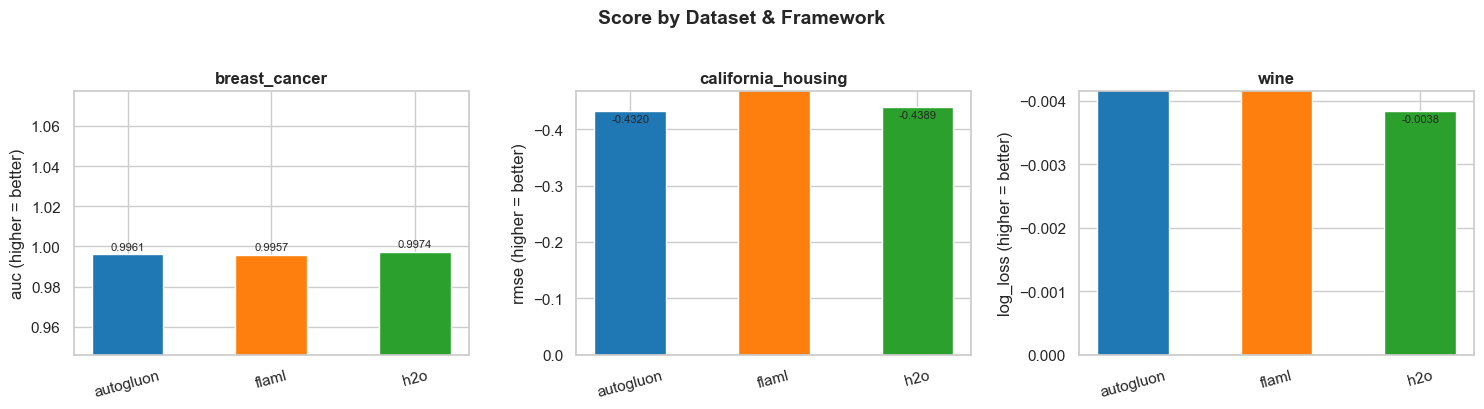

In [7]:
datasets   = sorted(df["dataset"].unique())
frameworks = sorted(df["framework"].unique())
n_ds       = len(datasets)

fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=False)
if n_ds == 1:
    axes = [axes]

colors = sns.color_palette("tab10", len(frameworks))
fw_color = dict(zip(frameworks, colors))

for ax, ds in zip(axes, datasets):
    sub = df[df["dataset"] == ds].set_index("framework")["score"].reindex(frameworks)
    bars = ax.bar(frameworks, sub.values, color=[fw_color[f] for f in frameworks], width=0.5)
    ax.set_title(ds, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    metric = df[df["dataset"] == ds]["metric_name"].iloc[0]
    ax.set_ylabel(f"{metric} (higher = better)")
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
    ax.tick_params(axis="x", rotation=15)
    # start y-axis near the minimum so differences are visible
    ymin = sub.dropna().min()
    ax.set_ylim(max(0, ymin * 0.95), sub.dropna().max() * 1.08)

fig.suptitle("Score by Dataset & Framework", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Score heatmap — framework × dataset
Color encodes normalized score within each dataset (so datasets with different metrics are comparable).

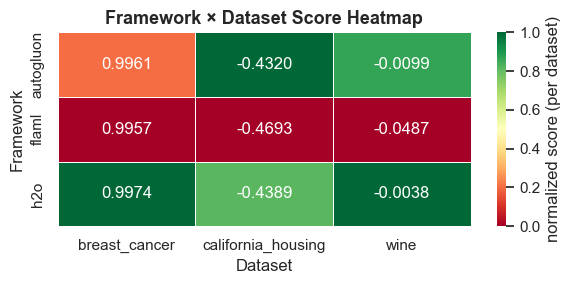

In [8]:
pivot = df.pivot_table(index="framework", columns="dataset", values="score", aggfunc="mean")

# normalize each column (dataset) to [0,1] so heatmap color is fair across metrics
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(max(6, len(datasets) * 1.8), max(3, len(frameworks) * 0.8)))
sns.heatmap(
    pivot_norm,
    annot=pivot.round(4),   # show raw score in cells
    fmt=".4f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "normalized score (per dataset)"},
)
ax.set_title("Framework × Dataset Score Heatmap", fontsize=13, fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Framework")
plt.tight_layout()
plt.show()

## 5. Training time comparison

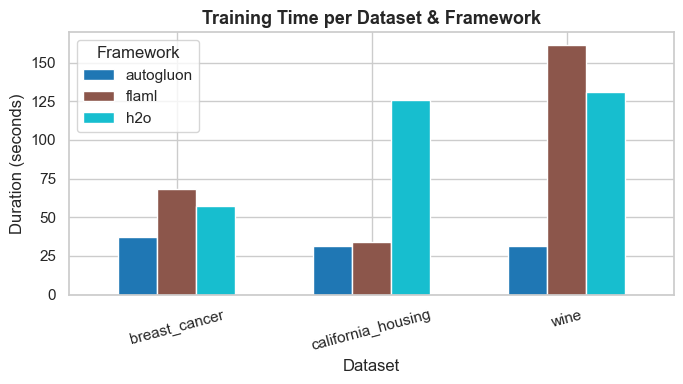

In [9]:
fig, ax = plt.subplots(figsize=(max(7, n_ds * 2), 4))

time_pivot = df.pivot_table(index="dataset", columns="framework", values="duration_s", aggfunc="mean")
time_pivot.plot(kind="bar", ax=ax, colormap="tab10", width=0.6)

ax.set_title("Training Time per Dataset & Framework", fontsize=13, fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Duration (seconds)")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Framework")
plt.tight_layout()
plt.show()

## 6. Score vs Time scatter (Pareto view)
Each point = one (framework, dataset) combo.  
Top-left = fast and accurate = best tradeoff.

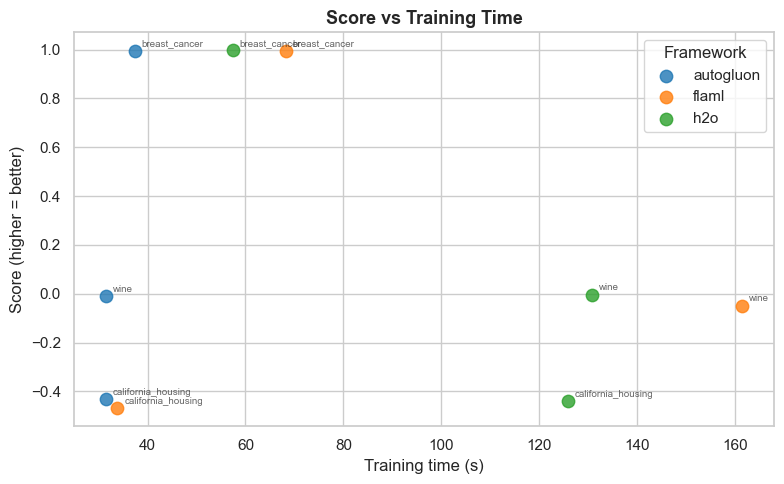

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for fw, grp in df.groupby("framework"):
    ax.scatter(
        grp["duration_s"], grp["score"],
        label=fw, s=80, alpha=0.8,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["dataset"],
            (row["duration_s"], row["score"]),
            textcoords="offset points", xytext=(5, 3),
            fontsize=7, alpha=0.7,
        )

ax.set_xlabel("Training time (s)")
ax.set_ylabel("Score (higher = better)")
ax.set_title("Score vs Training Time", fontsize=13, fontweight="bold")
ax.legend(title="Framework")
plt.tight_layout()
plt.show()

## 7. Average rank per framework
Rank 1 = best on a given dataset. Lower average rank = better overall.

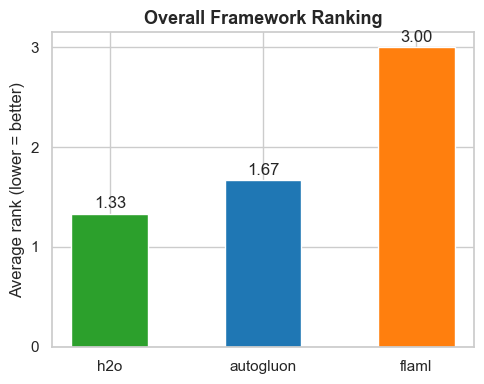

framework
h2o          1.333333
autogluon    1.666667
flaml        3.000000


In [11]:
# rank frameworks within each dataset (1 = highest score)
df["rank"] = df.groupby("dataset")["score"].rank(ascending=False, method="min")

avg_rank = df.groupby("framework")["rank"].mean().sort_values()

fig, ax = plt.subplots(figsize=(max(5, len(frameworks)), 4))
bars = ax.bar(avg_rank.index, avg_rank.values,
              color=[fw_color.get(f, "steelblue") for f in avg_rank.index], width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=2)
ax.set_ylabel("Average rank (lower = better)")
ax.set_title("Overall Framework Ranking", fontsize=13, fontweight="bold")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(avg_rank.to_string())